# **Handling Missing Values**

Missing data is an unavoidable challenge in data science. Missing values in a dataset can be handled using two main strategies: **removing the missing data** or **imputing (filling in) the values**. Choosing the right strategy directly impacts your model's accuracy, variance, and production stability. 


## **Univariate Imputation (Simple Imputer)**
This method fills missing values in a column using **only the statistical properties of that specific column**, ignoring all other variables.

### **Numerical Data (`num`)**

#### 1. Mean / Median Imputation
*   **What it is:** Fills gaps with the column's average (mean) or middle value (median). 
*   **Scikit-Learn Implementation:** 
    ```python
    from sklearn.impute import SimpleImputer
    imputer = SimpleImputer(strategy='mean')     # Or strategy='median'
    ```
*   **When to Use:**
    *   **Mean:** Best for symmetrically (normally) distributed numerical features missing completely at random.
    *   **Median:** Strictly preferred if the data is heavily skewed (e.g., salary, home prices) because it ignores outliers.
*   **When to Avoid:**
    *   When maintaining the original variance of the data is critical. Injecting a single value repeatedly collapses variance, creates an artificial "spike" at the center, and warps correlations.

#### 2. Random Sample Imputation
*   **What it is:** Fills gaps by randomly picking existing values from the same column.
*   **Scikit-Learn Implementation:** No native class. Must be coded manually via custom Transformers or Pandas (`df[col].sample()`).
*   **When to Use:**
    *   When you need to fill gaps while preserving the exact original variance and distribution shape of the dataset.
*   **When to Avoid:**
    *   In stable, production deployment environments. Because it relies on randomness, a pipeline processing the exact same record twice could yield two entirely different predictions, making it unstable.

#### 3. End of Distribution Imputation
*   **What it is:** Fills gaps with values located at the far tail of the distribution (e.g., `mean + 3 * standard deviations`).
*   **Scikit-Learn Implementation:** Extracted manually, then hardcoded via a constant imputer:
    ```python
    from sklearn.impute import SimpleImputer
    imputer = SimpleImputer(strategy='constant', fill_value=calculated_tail_value)
    ```
*   **When to Use:**
    *   When the fact that the data is missing carries a specific, hidden meaning (MNAR).
    *   When building Tree-based algorithms (like Random Forests or Gradient Boosting). Placing missing values out on an extreme tail allows trees to isolate and split missingness away cleanly.
*   **When to Avoid:**
    *   When training linear models or distance-based algorithms, as massive artificial outliers completely corrupt feature weights and distance calculations.




In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# A.) Deep Dive: Mean and Median Imputation

Mean and median imputation are the most widely used univariate techniques for handling missing numerical data. This strategy replaces missing entries using central tendency measures calculated from the available data within that specific column.

---

## 1. Core Mechanics: How it Works
When a feature column (e.g., `Age`) contains missing values (`NaN`), the statistical properties of the non-missing values are computed to fill the gaps.

*   **Mean Imputation:** Calculated by summing all non-missing values and dividing by the total count of those values. 
    $$\mu = \frac{1}{N} \sum_{i=1}^{N} x_i$$

    *   *Best suited for:* Symmetric, bell-shaped Gaussian distributions where the mean accurately represents the center.

*   **Median Imputation:** Calculated by sorting the non-missing values and identifying the exact middle value.

    *   *Best suited for:* Skewed (asymmetric) distributions or data containing heavy outliers (e.g., Salary, House Prices). The median remains stable because it is robust against extreme values.

---

## 2. Prerequisites for Use (When to Apply)
To safely apply mean or median imputation, your dataset should meet two primary criteria:

1.  **MCAR (Missing Completely At Random):** The reason data is missing must be completely independent of any observed or unobserved variables. If missingness carries a pattern or meaning, this method introduces severe statistical bias.

2.  **Low Missingness Rate ($< 5\%$):** It should only be applied when the missing data constitutes a tiny fraction of the total dataset. If more than 5% of your data is missing, the negative impacts on variance and correlation become too severe.

---

## 3. Advantages (Benefits)
*   **Extreme Simplicity:** It is exceptionally easy to understand, calculate, and implement.

*   **Production Speed:** Unlike multivariate models (KNN or MICE) that require complex mathematical computations during inference, mean/median values can be calculated once during training and saved as a constant value for blazing-fast production pipelines.

---

## 4. Disadvantages and Risks (Why to Avoid)

While simple, mean/median imputation introduces significant structural distortions into a dataset if overused:

### A. Distortion of the Distribution Shape
By repeatedly inserting the exact same value (the mean or median) into a column, you artificially compress the spread of the data. 

*   **The "Spike" Effect:** This collapses the variance and creates an artificial, unnatural spike at the center of your distribution. 
*   **Impact:** The standard deviation is falsely minimized, leading machine learning models to overestimate the certainty of that specific range.

### B. Vulnerability to Outliers (Mean Specific)

Because the mean takes every single value into account, extreme outliers will heavily pull the mean away from the true center of the data. Imputing with a warped mean shifts the entire feature space incorrectly.

### C. Alteration of Covariance and Correlation
When you add multiple identical points (e.g., replacing ten `NaN` values in `Age` with the mean value `29`), those imputed data points do not share any natural linear relationship with other columns (like `Salary`).

*   **Impact:** This artificially reduces the **Covariance** and dilutes the true **Correlation coefficient** between features. Linear models (like Linear/Logistic Regression) will consequently struggle to capture the true mathematical relationships between variables.


In [58]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

## 1. Using Pandas

In [59]:
# Import Data
df = pd.read_csv('../data/titanic_toy_1.csv')
print(f"Shape of DataFrame: {df.shape}")
df.head()

Shape of DataFrame: (891, 4)


,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [60]:
# Data information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       714 non-null    float64
 1   Fare      846 non-null    float64
 2   Family    891 non-null    int64  
 3   Survived  891 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 28.0 KB


In [61]:
# Missing Values Percentage
df.isnull().mean()*100

Age         19.865320
Fare         5.050505
Family       0.000000
Survived     0.000000
dtype: float64

In [62]:
# Split Data In Train Test Split
X = df.drop(columns=['Survived'])
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Shape of Train Data: {X_train.shape}")
print(f"Shape of Test Data: {X_test.shape}")

# Missing Values In training DataSet
print("\nMissing Values in X_train: \n", X_train.isnull().mean()*100)



Shape of Train Data: (712, 3)
Shape of Test Data: (179, 3)

Missing Values in X_train: 
 Age       19.662921
Fare       5.056180
Family     0.000000
dtype: float64


In [63]:
# Mean and Median Imputation for Age and Fare
mean_age = X_train['Age'].mean()
median_age = X_train['Age'].median()

mean_fare = X_train['Fare'].mean()
median_fare = X_train['Fare'].median()

In [64]:
# Fill Missing Values with Mean and Median

X_train['Age_mean'] = X_train['Age'].fillna(mean_age)
X_train['Age_median'] = X_train['Age'].fillna(median_age)

X_train['Fare_mean'] = X_train['Fare'].fillna(mean_fare)
X_train['Fare_median'] = X_train['Fare'].fillna(median_fare)

In [65]:
# Check
X_train.sample(5)

,Age,Fare,Family,Age_mean,Age_median,Fare_mean,Fare_median
573,NaN,7.75,0,29.498846,28.0,7.750000,7.75
47,NaN,7.75,0,29.498846,28.0,7.750000,7.75
438,64.0,263.00,5,64.000000,64.0,263.000000,263.00
860,41.0,NaN,2,41.000000,41.0,32.517788,14.40
32,NaN,7.75,0,29.498846,28.0,7.750000,7.75


In [66]:
# Evaluating Variance After Imputation
def check_variance(X, col, col_mean, col_median):
    
    print(f"Original Variance of {col}: ", X[col].var())
    print(f"Variance of {col} after mean imputation: ", X[col_mean].var())
    print(f"Variance of {col} after median imputation: ", X[col_median].var())



In [67]:
check_variance(X_train, 'Age', 'Age_mean', 'Age_median')

Original Variance of Age:  210.2517072477435
Variance of Age after mean imputation:  168.85193366872227
Variance of Age after median imputation:  169.20731007048155


In [68]:
check_variance(X_train, 'Fare', 'Fare_mean', 'Fare_median')

Original Variance of Fare:  2761.0314349486343
Variance of Fare after mean imputation:  2621.232374951235
Variance of Fare after median imputation:  2637.012481677765


In [69]:
# Distribution Change After Imputation
def Distribution_change(X, col, col_mean, col_median):
    
    fig = plt.figure()
    ax = fig.add_subplot(1, 1, 1)
    
    # Original distribution
    X[col].plot(kind='kde', alpha=0.5, label=f'{col}', color='red')
    
    # Variable Imputed with Mean
    X[col_mean].plot(kind='kde', alpha=0.5, label=f'{col_mean})', color='blue')
    
    # Variable Imputed with Median
    X[col_median].plot(kind='kde', alpha=0.5, label=f'{col_median}', color='green')
    
    plt.title(f'Distribution of {col} after Mean/Median imputation')
    plt.legend()
    plt.tight_layout()
    plt.show()



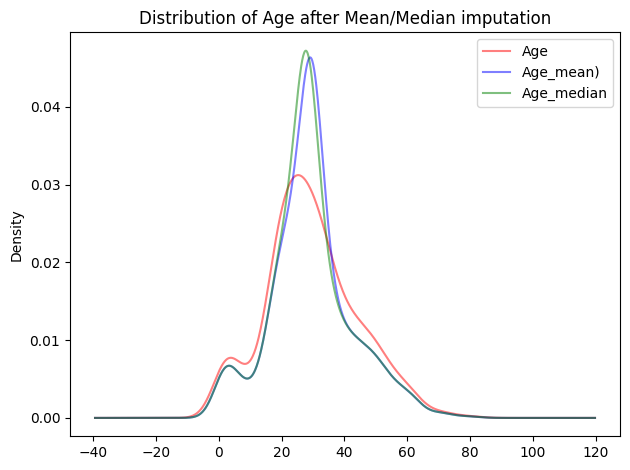

In [70]:
Distribution_change(X_train, 'Age', 'Age_mean', 'Age_median') 
# There is drastic difference between the original distribution and the mean/median imputed distributions. 
# The mean/median imputation changes the distribution of the variable significantly. 

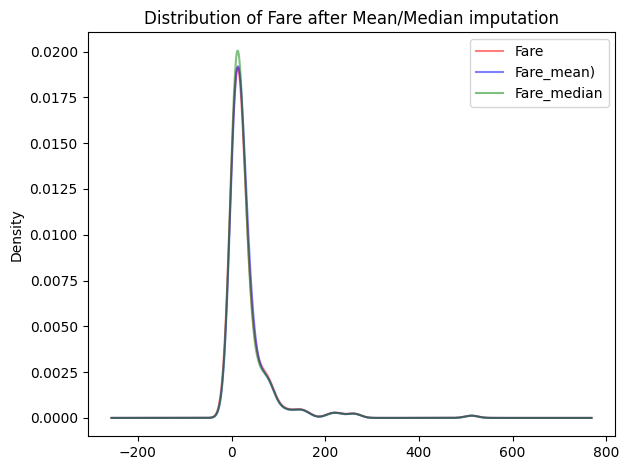

In [71]:
Distribution_change(X_train, 'Fare', 'Fare_mean', 'Fare_median') 
# There is no significant difference between the original distribution and the mean/median imputed distributions. 
# The mean/median imputation does not change the distribution of the variable significantly.

In [72]:
# Check for the covariance matrix after Mean/Median Imputation
cov_value = X_train.cov()
cov_value

,Age,Fare,Family,Age_mean,Age_median,Fare_mean,Fare_median
Age,210.251707,75.481375,-6.993325,210.251707,210.251707,71.193767,70.082085
Fare,75.481375,2761.031435,18.599163,60.224654,63.938058,2761.031435,2761.031435
Family,-6.993325,18.599163,2.830892,-5.616299,-5.587710,17.657433,17.672035
Age_mean,210.251707,60.224654,-5.616299,168.851934,168.851934,57.175304,56.282518
Age_median,210.251707,63.938058,-5.587710,168.851934,169.207310,60.700688,59.728510
Fare_mean,71.193767,2761.031435,17.657433,57.175304,60.700688,2621.232375,2621.232375
Fare_median,70.082085,2761.031435,17.672035,56.282518,59.728510,2621.232375,2637.012482


In [73]:
# Check for Corelation Matrix after Mean/Median Imputation
corr_value = X_train.corr()
corr_value

,Age,Fare,Family,Age_mean,Age_median,Fare_mean,Fare_median
Age,1.000000,0.091482,-0.319651,1.000000,1.000000,0.088944,0.087232
Fare,0.091482,1.000000,0.207193,0.088151,0.093496,1.000000,1.000000
Family,-0.319651,0.207193,1.000000,-0.256883,-0.255307,0.204981,0.204536
Age_mean,1.000000,0.088151,-0.256883,1.000000,0.998949,0.085941,0.084346
Age_median,1.000000,0.093496,-0.255307,0.998949,1.000000,0.091145,0.089416
Fare_mean,0.088944,1.000000,0.204981,0.085941,0.091145,1.000000,0.997003
Fare_median,0.087232,1.000000,0.204536,0.084346,0.089416,0.997003,1.000000


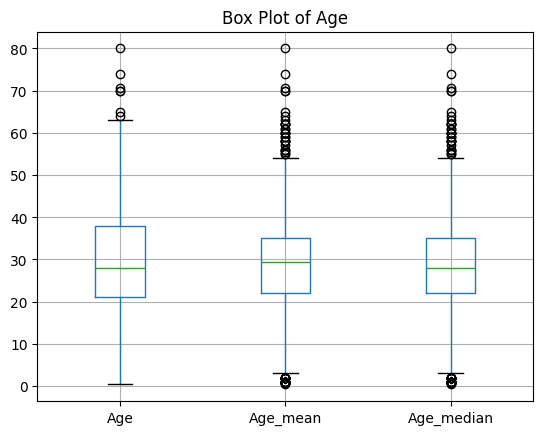

In [74]:
# Check for the Outliers in the data after Mean/Median Imputation
X_train[['Age', 'Age_mean', 'Age_median']].boxplot()
plt.title('Box Plot of Age')
plt.show()

# The Mean/Median Imputation introduces outliers in the data. 

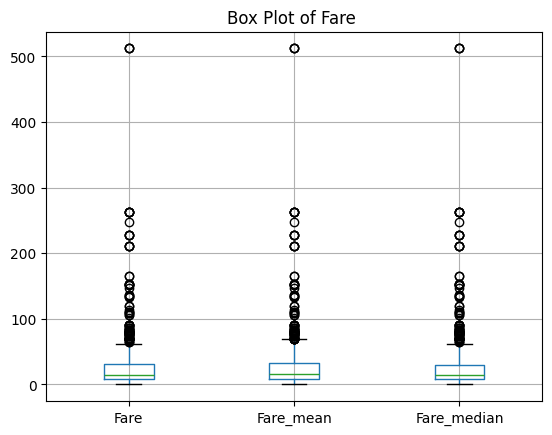

In [75]:
X_train[['Fare', 'Fare_mean', 'Fare_median']].boxplot()
plt.title('Box Plot of Fare ')
plt.show()

# There Is no Significant Outliers in the data after Mean/Median Imputation.

## 2. Using Sklearn

In [76]:
# Split the data into features and target variable
X = df.drop(columns=['Survived'])
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [77]:
# Create SimpleImputer for Mean and Median Imputation
imputer1 = SimpleImputer(strategy='mean')
imputer2 = SimpleImputer(strategy='median')

In [78]:
# Transform the data using ColumnTransformer
trf = ColumnTransformer([
    
    ('Imputer1', imputer1, ['Age']),
    ('Imputer2', imputer2, ['Fare'])
    
], remainder='passthrough')

# Fit the ColumnTransformer to the data
trf.fit(X_train)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('Imputer1', ...), ('Imputer2', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and

In [79]:
# Calculated Mean and Median for Age and Fare columns
mean_Age = trf.named_transformers_['Imputer1'].statistics_[0]
median_Fare = trf.named_transformers_['Imputer2'].statistics_[0]

print(f"Mean Age: { mean_Age:.3f}")
print(f"Median Fare:  {median_Fare}")

Mean Age: 29.499
Median Fare:  14.4


In [80]:
# Transform the X_train and X_test
X_train_imputed = trf.transform(X_train)
X_test_imputed = trf.transform(X_test)

# Display the transformed data
X_train_imputed = pd.DataFrame(X_train_imputed, columns=X_train.columns)
X_test_imputed = pd.DataFrame(X_test_imputed, columns=X_test.columns)
X_train_imputed.sample(5)

,Age,Fare,Family
172,1.0,11.1333,2
828,NaN,7.7500,0
792,NaN,69.5500,10
474,22.0,9.8375,0
423,28.0,14.4000,2


 > Note : 
   1. After applying Mean/Median imputation we can check to its distribution, correlation and covariance just like before. 
2. This particular Way of Transforming data helps when we create a pipeline where the same transformation is applied to both training and testing sets. 
3. This ensures that the transformations are consistent across different datasets.


# B.) Deep Dive: Arbitrary Value Imputation

Arbitrary Value Imputation is a univariate technique that replaces all missing values in a column with a single, pre-determined, and explicitly chosen constant value. The chosen value is deliberately selected to stand completely outside the normal, expected range of that feature.

---

## 1. Core Mechanics: How it Works
When a feature column contains missing values (`NaN`), the data we selects an arbitrary constant that cannot be confused with real data points.

*   **Numerical Data Examples:** Replacing `NaN` with values like `-999`, `-1`, or `9999`. For instance, if the feature is `Age` (where values must be positive), using `-1` instantly flags that data point as missing.

*   **Categorical Data Examples:** Replacing `NaN` with text strings like `"Missing"`, `"Unknown"`, or `"Other"`.

*   **Scikit-Learn Implementation:** 
    ```python
    from sklearn.impute import SimpleImputer
    
    # For Numerical features
    numerical_imputer = SimpleImputer(strategy='constant', fill_value=-1)
    
    # For Categorical features
    categorical_imputer = SimpleImputer(strategy='constant', fill_value='Missing')
    ```

---

## 2. Prerequisites for Use (When to Apply)
To apply arbitrary value imputation safely, your pipeline should meet the following conditions:

1.  **MNAR (Missing Not At Random):** This is the ideal strategy when the missingness itself carries crucial structural information. For example, a missing entry in `Years at Current Job` might intentionally mean the person is currently unemployed.

2.  **Tree-Based Machine Learning Models:** It should primarily be used when you plan to train non-linear algorithms such as **Decision Trees, Random Forests, or Gradient Boosting Models (XGBoost, LightGBM)**.

---

## 3. Advantages (Benefits)

### A. Clear Segregation of Missing Data
By using an extreme or distinct value, you explicitly tell the machine learning algorithm: *"This data was missing, and that fact is important."* Tree-based models can easily detect this constant and create a clean, dedicated split (e.g., `if Age == -1`) to route missing profiles down a specialized decision path.

### B. High Production Stability (Deterministic)
Unlike random sampling methods, this approach is entirely deterministic. The exact same constant is injected every single time, ensuring absolute consistency when deploying the model to live production scoring systems.

---

## 4. Disadvantages and Risks (Why to Avoid)

### A. Severe Distortion of Linear Assumptions
Injecting arbitrary extreme constants completely ruins the statistical integrity of linear relationships.

*   **Impact on Linear Models:** If you change twenty missing `Age` values to `-999`, a Linear Regression model will interpret those rows as people who are literally negative one-thousand years old. This warps the slope of your line, corrupts feature weights (coefficients), and destroys model accuracy.

### B. Distortion of Distance Metrics
Algorithms that rely on spatial distances between data points will be heavily biased by arbitrary numbers.

*   **Impact on Distance-Based Models:** In algorithms like **K-Nearest Neighbors (KNN), K-Means Clustering, or Support Vector Machines (SVMs)**, a value of `-999` or `9999` creates a massive geometric distance between rows. The algorithm will group or separate data points purely based on the presence of the arbitrary flag, completely masking the influence of real data features.

### C. Artificial Skewness and Outliers
This technique intentionally introduces extreme outliers into your dataset. If you mistakenly pass this imputed column into a feature scaling step (like `MinMaxScaler`), the entire scale will compress toward 0 because of the massive gap between `-999` and normal data points.


In [127]:
# Split Data In Train Test Split
X = df.drop(columns=['Survived'])
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Shape of Train Data: {X_train.shape}")
print(f"Shape of Test Data: {X_test.shape}")

# Missing Values In training DataSet
print("\nMissing Values in X_train: \n", X_train.isnull().mean()*100)


Shape of Train Data: (712, 3)
Shape of Test Data: (179, 3)

Missing Values in X_train: 
 Age       19.662921
Fare       5.056180
Family     0.000000
dtype: float64


In [128]:
imputer_avi1 = SimpleImputer(strategy='constant', fill_value=-1)
imputer_avi2 = SimpleImputer(strategy='constant', fill_value=999)

trf = ColumnTransformer([
    ('Age_impute', imputer_avi1, ['Age']),
    ('Fare_impute', imputer_avi2, ['Fare'])
],remainder='passthrough')

trf.fit(X_train)


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('Age_impute', ...), ('Fare_impute', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`

In [129]:
trf.named_transformers_['Age_impute'].statistics_[0]

-1

In [130]:
X_train_imputed = trf.transform(X_train)
X_test_imputed = trf.transform(X_test)

X_train_imputed = pd.DataFrame(X_train_imputed, columns=X_train.columns)
X_test_imputed = pd.DataFrame(X_test_imputed, columns=X_test.columns)
X_train_imputed.sample(5)

,Age,Fare,Family
573,34.00,999.0000,1.0
342,22.00,7.2500,0.0
531,2.00,39.6875,5.0
223,-1.00,79.2000,0.0
662,0.83,999.0000,2.0


In [131]:
# Distribution Change After Imputation
def Distribution_change(X, X_tran, col):
    
    fig = plt.figure()
    ax = fig.add_subplot(1, 1, 1)
    
    
    # Original distribution
    X[col].plot(kind='kde', alpha=0.5, label=f'{col} Before', color='red')
    
    # Variable Imputed value
    X_tran[col].plot(kind='kde', alpha=0.5, label=f'{col} After', color='blue')
    
    plt.title(f'Distribution of {col} after Mean/Median imputation')
    plt.legend()
    plt.tight_layout()
    plt.show()

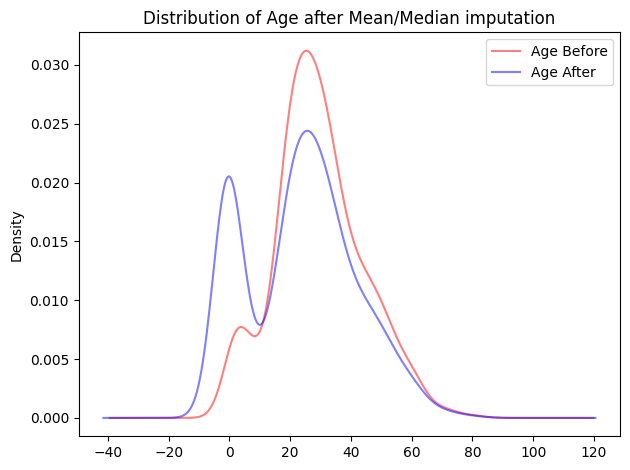

In [ ]:
Distribution_change(X_train, X_train_imputed, 'Age')
# There is drastic difference between the original distribution and the mean/median imputed distributions. 
# The mean/median imputation changes the distribution of the variable significantly. 

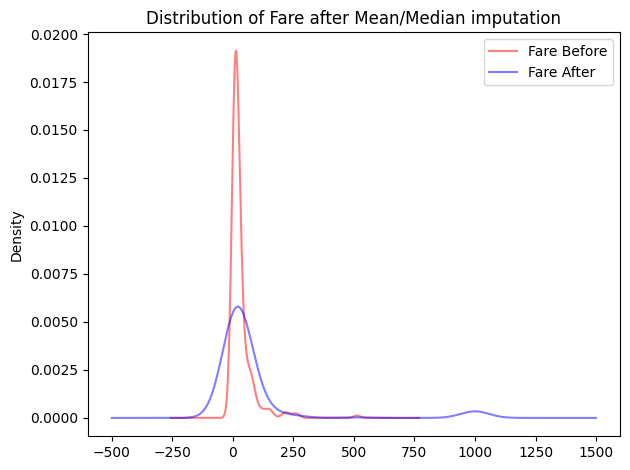

In [133]:
Distribution_change(X_train, X_train_imputed, 'Fare')
# There is no significant difference between the original distribution and the mean/median imputed distributions. 
# The mean/median imputation does not change the distribution of the variable significantly.

# C.) Deep Dive: End of Distribution Imputation

End of Distribution Imputation is a univariate technique that automatically calculates an extreme value at the far edge (tail) of the feature's distribution and uses it to replace all missing entries. It acts as a *statistically controlled version of Arbitrary Value Imputation.*

---

## 1. Core Mechanics: How it Works
When a feature column contains missing values (`NaN`), the algorithm calculates the statistical boundaries of the distribution's tail based on the non-missing data. The exact calculation depends on the shape of the data:

*   **For Normally Distributed Features:** The value is placed 3 standard deviations (σ) away from the mean (μ).

    *   *Right-tail threshold:* Value = μ + 3σ
    *   *Left-tail threshold:* Value = μ - 3σ

*   **For Skewed Distributions:** The value is calculated using the Interquartile Range (IQR) to place it beyond the extreme outliers.

    *   *Right-tail threshold:* Q3 + 3 × IQR
    *   *Left-tail threshold:* Q1 - 3 × IQR

*   **Scikit-Learn Implementation:** Scikit-learn does not have a native, automated class for this. It must be computed manually and passed into a constant imputer:
    ```python
    from sklearn.impute import SimpleImputer

    # 1. Calculate the end of distribution threshold (Right-tail example)
    mean_val = df['Age'].mean()
    std_val = df['Age'].std()
    extreme_value = mean_val + (3 * std_val)

    # 2. Apply via SimpleImputer
    imputer = SimpleImputer(strategy='constant', fill_value=extreme_value)
    ```

---

## 2. Prerequisites for Use (When to Apply)
To effectively use end of distribution imputation, your project workflow must meet these conditions:

1.  **MNAR (Missing Not At Random):** The missingness must contain structural meaning. By placing the imputed value at the absolute edge of the distribution, you visually and mathematically isolate the missing rows from the rest of the data.

2.  **Tree-Based Machine Learning Models:** This technique is purpose-built for non-linear, tree-based models like **Decision Trees, Random Forests, Gradient Boosting (XGBoost, LightGBM, CatBoost)**.

---

## 3. Advantages (Benefits)

### A. Effortless Split Creation for Trees
Tree-based algorithms work by making binary splits (e.g., `Value <= X`). By placing all missing observations together at the extreme end of the distribution, a tree model can isolate all missing records into their own separate node with a single, clean split.

### B. Automated and Standardized
Unlike Arbitrary Value Imputation—where a data scientist must manually guess an arbitrary number (like `-999` or `9999`) for every single column—this method relies on pure statistics. It scales automatically across multiple features by adjusting itself to the unique variance and range of each column.

---

## 4. Disadvantages and Risks (Why to Avoid)

### A. Catastrophic for Linear and Distance Models
Because this method intentionally creates a massive block of artificial outliers, it completely distorts the mathematical assumptions of several algorithm families:
*   **Linear/Logistic Regression:** The extreme values heavily pull and warp the regression line coefficient slope, degrading model predictive power.
*   **KNN / K-Means Clustering:** Distance-based metrics will see these extreme values as infinitely far away from the rest of the dataset. Rows with missing values will cluster exclusively with each other, completely masking their true underlying patterns.

### B. Masking Real Outliers
If your dataset already contains actual, organic outliers at the tail end, injecting a massive spike of artificial data points at that exact location makes it incredibly difficult for anomaly detection models or standard filters to separate genuine data outliers from missing data flags.


In [136]:
# Split Data In Train Test Split
X = df.drop(columns=['Survived'])
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Shape of Train Data: {X_train.shape}")
print(f"Shape of Test Data: {X_test.shape}")

# Missing Values In training DataSet
print("\nMissing Values in X_train: \n", X_train.isnull().mean()*100)

Shape of Train Data: (712, 3)
Shape of Test Data: (179, 3)

Missing Values in X_train: 
 Age       19.662921
Fare       5.056180
Family     0.000000
dtype: float64


In [152]:
# 1. Calculating the end of distribution threshold (Right trail Example)

mean_val_age = X_train['Age'].mean()
std_val_age = X_train['Age'].std()

mean_val_fare = X_train['Fare'].mean()
std_val_fare = X_train['Fare'].std()

extreme_value_age = mean_val_age - ( 3 * std_val_age )
extreme_value_fare = mean_val_fare - ( 3 * std_val_fare )


In [153]:
imputer_age = SimpleImputer(strategy='constant', fill_value=extreme_value_age)
imputer_fare = SimpleImputer(strategy='constant', fill_value=extreme_value_fare)

trf = ColumnTransformer([
    ('Age_impute', imputer_age, ['Age']),
    ('Fare_impute', imputer_fare, ['Fare'])
], remainder='passthrough')

trf.fit(X_train)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('Age_impute', ...), ('Fare_impute', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`

In [154]:
trf.named_transformers_['Age_impute'].statistics_[0]

-14.001330457630853

In [155]:
X_train_imputed = trf.transform(X_train)
X_test_imputed = trf.transform(X_test)

X_train_imputed = pd.DataFrame(X_train_imputed, columns=X_train.columns)
X_test_imputed = pd.DataFrame(X_test_imputed, columns=X_test.columns)
X_train_imputed.sample(5)

,Age,Fare,Family
4,6.0,31.2750,6.0
315,27.0,13.8583,1.0
422,4.0,39.0000,3.0
220,55.0,16.0000,0.0
497,25.0,7.7750,1.0


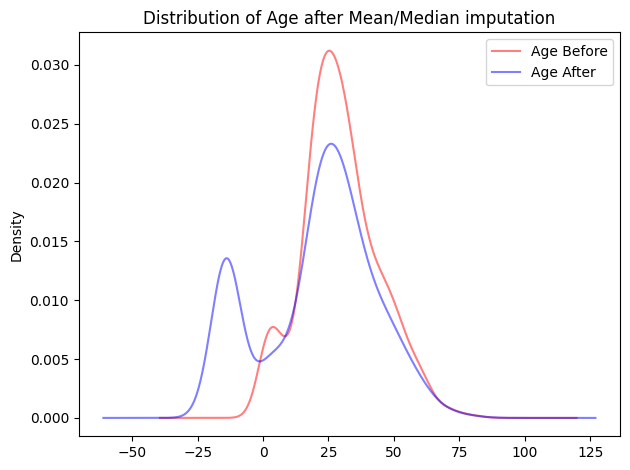

In [ ]:
Distribution_change(X_train, X_train_imputed, 'Age')
# There is drastic difference between the original distribution and the mean/median imputed distributions. 
# The mean/median imputation changes the distribution of the variable significantly. 

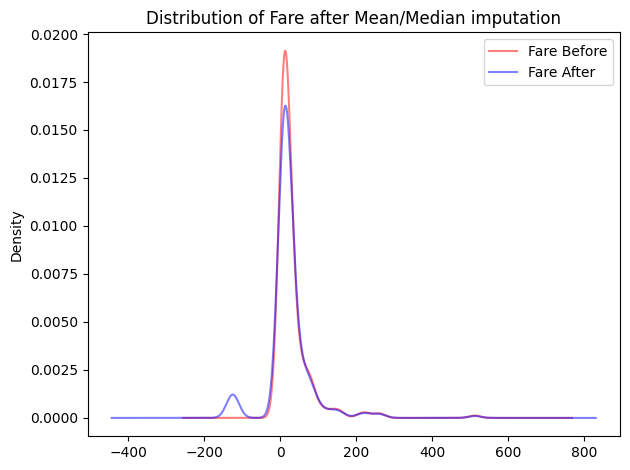

In [157]:
Distribution_change(X_train, X_train_imputed, 'Fare')
# There is no significant difference between the original distribution and the mean/median imputed distributions. 
# The mean/median imputation does not change the distribution of the variable significantly.